In [18]:
import scanpy as sc
import matplotlib as mpl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/epithelial.h5ad')
# l_adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/lymphoid.h5ad')

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [17]:
for celltype in adata.obs['tissue'].unique():
    print(celltype)

ascending colon
ileum
rectum
small intestine
colon
caecum
transverse colon
sigmoid colon
duodenum
jejunum
descending colon
vermiform appendix


## Dotplots for rare cell types

In [52]:
adata.var

,gene_id,gene_symbol,mt,ribo,hb,n_cells,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,feature_is_filtered
ENSG00000000003,ENSG00000000003,TSPAN6,False,False,False,130826,195140,0.094287,0.090103,94.224985,318599,12.671692,False,0.076050,1.038674,-1.111607,False
ENSG00000000005,ENSG00000000005,TNMD,False,False,False,3135,4878,0.001594,0.001593,99.855639,5387,8.591930,False,0.001454,0.667250,-0.527142,False
ENSG00000000419,ENSG00000000419,DPM1,False,False,False,254820,329289,0.129758,0.122003,90.254951,438457,12.991019,False,0.150211,1.092318,inf,False
ENSG00000000457,ENSG00000000457,SCYL3,False,False,False,136455,175516,0.060628,0.058861,94.805742,204864,12.230107,False,0.063990,1.189661,0.017007,False
ENSG00000000460,ENSG00000000460,C1orf112,False,False,False,57454,70285,0.024555,0.024258,97.919971,82971,11.326258,False,0.025647,1.210943,-0.018293,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288380,ENSG00000288380,CRIPAK,False,False,False,16897,20886,0.006547,0.006525,99.381895,22122,10.004373,False,0.008141,0.529624,-0.047372,False
ENSG00000288398,ENSG00000288398,AL109627.1,False,False,False,2644,3151,0.000945,0.000944,99.906749,3193,8.069029,False,0.001483,0.521270,0.030542,False
ENSG00000288436,ENSG00000288436,AC024558.2,False,False,False,1438,1631,0.000532,0.000532,99.951732,1799,7.495542,False,0.001226,0.269041,-0.007030,False
ENSG00000288459,ENSG00000288459,AL512357.2,False,False,False,2888,3349,0.001025,0.001024,99.900889,3462,8.149891,False,0.001375,0.174228,0.044378,False


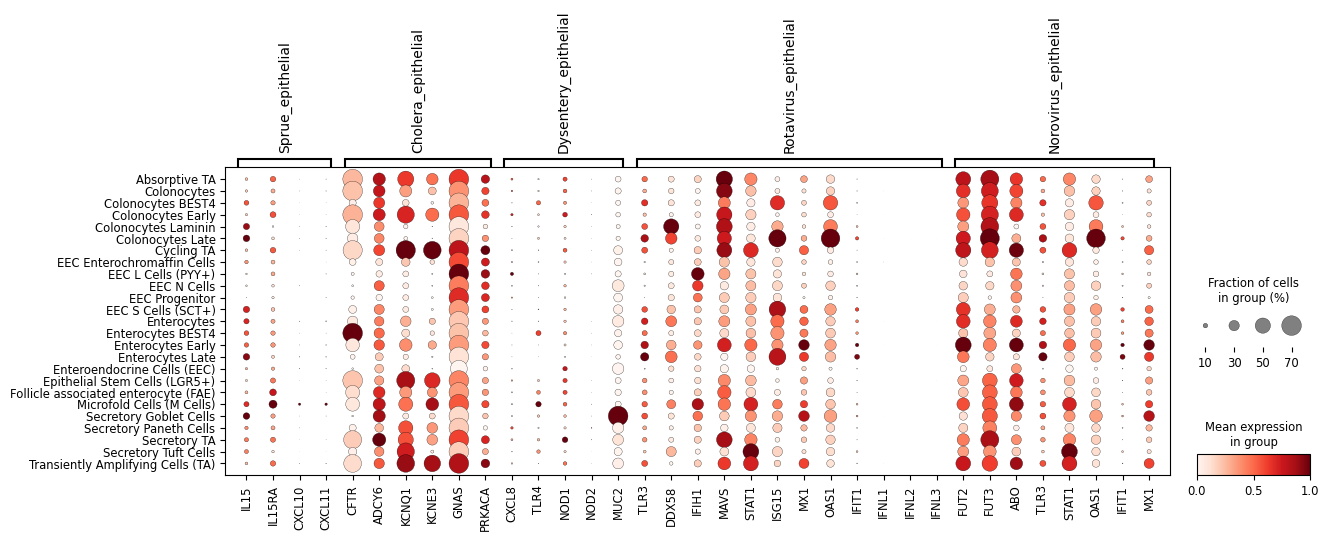

In [5]:
type_col = "Prelim annotation"

sprue_epithelial_markers = [
    "IL15",
    "IL15RA",
    "CXCL10",
    "CXCL11",
]

cholera_epithelial_markers = [
    "CFTR",
    "ADCY6",
    "KCNQ1",
    "KCNE3",
    "GNAS",
    "PRKACA",
]

dysentery_epithelial_markers = [
    "CXCL8",
    "TLR4",
    "NOD1",
    "NOD2",
    "MUC2",
]

rotavirus_epithelial_markers = [
    "TLR3",
    "DDX58",
    "IFIH1",
    "MAVS",
    "STAT1",
    "ISG15",
    "MX1",
    "OAS1",
    "IFIT1",
    "IFNL1",
    "IFNL2",
    "IFNL3",
]

norovirus_epithelial_markers = [
    "FUT2",
    "FUT3",
    "ABO",
    "TLR3",
    "STAT1",
    "OAS1",
    "IFIT1",
    "MX1",
]

other_daly_epithelial_markers = {
    "ETEC_secretory": [
        "GUCY2C",
        "GUCA2A",
        "GUCA2B",
        "SLC26A3",
        "SLC9A3",
    ],
    "Cryptosporidium_infection_response": [
        "STAT1",
        "ISG15",
        "MX1",
        "OAS1",
        "IFIT1",
    ],
    "C_difficile_inflammatory_diarrhea": [
        "SLC26A3",
    ],
}

marker_panels = {
    "Sprue_epithelial": sprue_epithelial_markers,
    "Cholera_epithelial": cholera_epithelial_markers,
    "Dysentery_epithelial": dysentery_epithelial_markers,
    "Rotavirus_epithelial": rotavirus_epithelial_markers,
    "Norovirus_epithelial": norovirus_epithelial_markers,
    "Other_DALY_epithelial": other_daly_epithelial_markers,
}


sym_col = "gene_symbol"
sym = adata.var[sym_col].astype(str)

marker_panels = {k: [g for g in v if (sym == g).any()] for k, v in marker_panels.items()}
marker_panels = {k: v for k, v in marker_panels.items() if len(v) > 0}

mpl.rcdefaults()
mpl.rcParams["figure.figsize"] = (9, 4)

if len(marker_panels) == 0:
    raise ValueError("None of the marker genes were found in adata.var_names")

# Make dotplot with explicit figsize to avoid the gridspec error
sc.pl.dotplot(
    adata[~adata.obs["Prelim annotation"].isin(["doublet", "lowQ", "Plasma Cells", "Monocytes"])].copy(),
    var_names=marker_panels,
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    figsize=(14, 4),
    show=True,
)

In [ ]:
type_col = "Prelim annotation"

sprue_epithelial_markers = [
    "IL15",
    "IL15RA",
    "CXCL10",
    "CXCL11",
]

cholera_epithelial_markers = [
    "CFTR",
    "ADCY6",
    "KCNQ1",
    "KCNE3",
    "GNAS",
    "PRKACA",
]

dysentery_epithelial_markers = [
    "CXCL8",
    "TLR4",
    "NOD1",
    "NOD2",
    "MUC2",
]

rotavirus_epithelial_markers = [
    "TLR3",
    "DDX58",
    "IFIH1",
    "MAVS",
    "STAT1",
    "ISG15",
    "MX1",
    "OAS1",
    "IFIT1",
    "IFNL1",
    "IFNL2",
    "IFNL3",
]

norovirus_epithelial_markers = [
    "FUT2",
    "FUT3",
    "ABO",
    "TLR3",
    "STAT1",
    "OAS1",
    "IFIT1",
    "MX1",
]

other_daly_epithelial_markers = {
    "ETEC_secretory": [
        "GUCY2C",
        "GUCA2A",
        "GUCA2B",
        "SLC26A3",
        "SLC9A3",
    ],
    "Cryptosporidium_infection_response": [
        "STAT1",
        "ISG15",
        "MX1",
        "OAS1",
        "IFIT1",
    ],
    "C_difficile_inflammatory_diarrhea": [
        "SLC26A3",
    ],
}

marker_panels = {
    "Sprue_epithelial": sprue_epithelial_markers,
    "Cholera_epithelial": cholera_epithelial_markers,
    "Dysentery_epithelial": dysentery_epithelial_markers,
    "Rotavirus_epithelial": rotavirus_epithelial_markers,
    "Norovirus_epithelial": norovirus_epithelial_markers,
    "Other_DALY_epithelial": other_daly_epithelial_markers,
}


sym_col = "gene_symbol"
sym = adata.var[sym_col].astype(str)

marker_panels = {k: [g for g in v if (sym == g).any()] for k, v in marker_panels.items()}
marker_panels = {k: v for k, v in marker_panels.items() if len(v) > 0}

mpl.rcdefaults()
mpl.rcParams["figure.figsize"] = (9, 4)

if len(marker_panels) == 0:
    raise ValueError("None of the marker genes were found in adata.var_names")

# Make dotplot with explicit figsize to avoid the gridspec error
sc.pl.dotplot(
    adata[~adata.obs["Prelim annotation"].isin(["doublet", "lowQ", "Plasma Cells", "Monocytes"])].copy(),
    var_names=marker_panels,
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    figsize=(14, 4),
    show=True,
)

In [13]:
adata

AnnData object with n_obs × n_vars = 274859 × 36353
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'closest_GCA_celltype_x', 'cell_type_atlas', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'co

In [16]:
for x in adata.obs['sample_collection_method'].unique():
    print(x)

biopsy
surgical resection


## Homeostatic functions 

In [30]:
base = '/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/'
paths = {
    "epithelial": os.path.join(base, "epithelial.h5ad"),
    "myeloid": os.path.join(base, "myeloid.h5ad"),
    "lymphoid": os.path.join(base, "lymphoid.h5ad"),
    "stroma": os.path.join(base, "stroma.h5ad"),
}

adata_epi = sc.read_h5ad(paths["epithelial"])
adata_epi

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 274859 × 36353
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'closest_GCA_celltype_x', 'cell_type_atlas', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'co

In [63]:
required = [
    "cxg_tissue_ontology",
    "sample_collection_method",
    "sampled_site_condition",
    "sex_ontology_term",
    "age_range",
    "dataset_id",
    "donor_id",
    "sample_id",
]
missing = [c for c in required if c not in adata_epi.obs.columns]

celltype_col = "Prelim annotation"

print(missing)


[]


In [44]:
import pandas as pd
import numpy as np

def map_segment_and_layer_str(tissue_str):
    if tissue_str is None or (isinstance(tissue_str, float) and np.isnan(tissue_str)):
        return ("unknown", "unknown")

    s = str(tissue_str).strip().lower()

    layer = "unknown"
    if "epithelium" in s:
        layer = "epithelium"
    elif "mucosa" in s:
        layer = "mucosa"

    seg = "unknown"

    if "duoden" in s or s == "duodenum":
        seg = "duodenum"
    elif "jejun" in s:
        seg = "jejunum"
    elif "small intestine" in s:
        seg = "small_intestine"
    elif "ile" in s and "colon" not in s:
        seg = "ileum"
    elif "appendix" in s:
        seg = "appendix"
    elif "rectum" in s:
        seg = "rectum"
    elif (
        "sigmoid" in s or "descending colon" in s or "transverse colon" in s or
        "ascending colon" in s or "caecum" in s or "mucosa of caecum" in s or
        "colon" in s or "colonic" in s
    ):
        seg = "colon"

    return (seg, layer)

vals = adata_epi.obs["cxg_tissue_ontology"].astype(str).tolist()
mapped = [map_segment_and_layer_str(v) for v in vals]
mapped_df = pd.DataFrame(mapped, columns=["segment", "tissue_layer"], index=adata_epi.obs_names)

adata_epi.obs["segment"] = mapped_df["segment"].values
adata_epi.obs["tissue_layer"] = mapped_df["tissue_layer"].values

adata_epi.obs["segment"].value_counts(dropna=False)


segment
ileum              182806
colon               74072
duodenum             6837
rectum               5206
jejunum              3930
small_intestine      1910
appendix               98
Name: count, dtype: int64

In [49]:
adata_epi.var_names = adata_epi.var['gene_symbol'].astype("string")

In [51]:
adata_epi.var_names_make_unique()
adata_epi.var_names

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'AC010332.3', 'FP325313.3', 'AL132709.8', 'AC079772.1', 'AL160391.1',
       'CRIPAK', 'AL109627.1', 'AC024558.2', 'AL512357.2', 'AL138899.3'],
      dtype='string', name='gene_symbol', length=36353)

In [52]:
def present_genes(adata, genes):
    v = set(adata.var['gene_symbol'])
    return [g for g in genes if g in v]

# BIS and IHC gene sets
# These are starter sets. You can tune them later, but keep them stable across segments.

bis_sealing = [
    "EPCAM", "CDH1", "TJP1", "TJP2", "OCLN",
    "CLDN1", "CLDN3", "CLDN4", "CLDN7", "CLDN8",
]
bis_shielding = [
    "MUC2", "MUC1", "TFF3", "AGR2", "SPDEF", "SPINK4",
    "BPIFB1", "PIGR",
]
bis_damage = [
    "VIM", "IFIT1", "IFIT2", "ISG15", "CXCL8", "CXCL2",
    "JUN", "FOS", "ATF3", "HSPA1A", "HSPA1B",
]

ihc_secretion = [
    "CFTR", "SLC26A3", "SLC26A2", "SLC12A2", "KCNQ1", "KCNE3",
]
ihc_absorption = [
    "SLC9A3", "SLC9A2", "SLC26A6", "SLC5A1", "SLC2A5",
    "ATP1A1", "ATP1B1",
]

bis_sealing = present_genes(adata_epi, bis_sealing)
bis_shielding = present_genes(adata_epi, bis_shielding)
bis_damage = present_genes(adata_epi, bis_damage)
ihc_secretion = present_genes(adata_epi, ihc_secretion)
ihc_absorption = present_genes(adata_epi, ihc_absorption)

(len(bis_sealing), len(bis_shielding), len(bis_damage), len(ihc_secretion), len(ihc_absorption))


(10, 8, 11, 6, 7)

In [53]:
def safe_score_genes(adata, genes, score_name):
    if len(genes) == 0:
        adata.obs[score_name] = np.nan
        return
    sc.tl.score_genes(adata, gene_list=genes, score_name=score_name, use_raw=False)

safe_score_genes(adata_epi, bis_sealing, "bis_sealing")
safe_score_genes(adata_epi, bis_shielding, "bis_shielding")
safe_score_genes(adata_epi, bis_damage, "bis_damage")

safe_score_genes(adata_epi, ihc_secretion, "ihc_secretion")
safe_score_genes(adata_epi, ihc_absorption, "ihc_absorption")

adata_epi.obs["BIS_raw"] = adata_epi.obs["bis_sealing"] + adata_epi.obs["bis_shielding"] - adata_epi.obs["bis_damage"]
adata_epi.obs["IHC_raw"] = adata_epi.obs["ihc_absorption"] - adata_epi.obs["ihc_secretion"]

adata_epi.obs[["BIS_raw", "IHC_raw"]].describe()


,BIS_raw,IHC_raw
count,274859.000000,274859.000000
mean,11.400485,1.292219
std,35.932573,4.838465
min,-95.815758,-94.840524
25%,-2.744167,0.013998
50%,0.809242,1.217108
75%,9.663258,2.875182
max,812.662727,40.689150


In [55]:
def zscore_within_group(df, value_col, group_col):
    out = df[value_col].copy()
    for g, idx in df.groupby(group_col).groups.items():
        x = df.loc[idx, value_col].astype(float)
        mu = np.nanmean(x.values)
        sd = np.nanstd(x.values)
        if np.isfinite(sd) and sd > 0:
            out.loc[idx] = (x - mu) / sd
        else:
            out.loc[idx] = np.nan
    return out

adata_epi.obs["BIS_seg_z"] = zscore_within_group(adata_epi.obs, "BIS_raw", "segment")
adata_epi.obs["IHC_seg_z"] = zscore_within_group(adata_epi.obs, "IHC_raw", "segment")


In [65]:
# Phase space points as segment x state pseudobulk
if celltype_col is None:
    raise ValueError("No cell type column found. Set celltype_col manually.")

df = adata_epi.obs[
    ["segment", "tissue_layer", celltype_col, "BIS_raw", "IHC_raw", "BIS_seg_z", "IHC_seg_z",
     "sampled_site_condition", "sample_collection_method", "sex_ontology_term", "age_range",
     "dataset_id", "donor_id", "sample_id"]
].copy()

df.rename(columns={celltype_col: "cell_state"}, inplace=True)

state_summary = (
    df.groupby(["segment", "cell_state"], dropna=False)
      .agg(
          BIS_raw_mean=("BIS_raw", "mean"),
          IHC_raw_mean=("IHC_raw", "mean"),
          BIS_seg_z_mean=("BIS_seg_z", "mean"),
          IHC_seg_z_mean=("IHC_seg_z", "mean"),
          n_cells=("BIS_raw", "size"),
          n_donors=("donor_id", pd.Series.nunique),
          n_samples=("sample_id", pd.Series.nunique),
      )
      .reset_index()
)

state_summary.sort_values(["segment", "n_cells"], ascending=[True, False]).head(10)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_87676/3679343849.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["segment", "cell_state"], dropna=False)


,segment,cell_state,BIS_raw_mean,IHC_raw_mean,BIS_seg_z_mean,IHC_seg_z_mean,n_cells,n_donors,n_samples
3,appendix,Colonocytes Early,-1.432038,2.238453,-0.090114,-0.135369,31,2.0,4.0
1,appendix,Colonocytes,-0.613391,2.181672,-0.046974,-0.162538,21,2.0,3.0
0,appendix,Absorptive TA,24.978249,4.657422,1.301628,1.022069,9,2.0,3.0
17,appendix,Epithelial Stem Cells (LGR5+),-15.378098,2.024321,-0.825029,-0.237828,9,2.0,4.0
24,appendix,Secretory TA,-4.278807,2.953476,-0.240130,0.206757,8,2.0,3.0
18,appendix,Follicle associated enterocyte (FAE),1.901869,3.313411,0.085573,0.378981,6,2.0,2.0
6,appendix,Cycling TA,-5.532273,0.894440,-0.306184,-0.778458,4,2.0,2.0
26,appendix,Transiently Amplifying Cells (TA),-6.500758,1.491652,-0.357220,-0.492702,4,1.0,1.0
2,appendix,Colonocytes BEST4,-5.208131,2.776620,-0.289102,0.122135,3,2.0,3.0
19,appendix,Microfold Cells (M Cells),-10.280909,3.417900,-0.556422,0.428977,1,1.0,1.0


In [ ]:
for x in 

In [77]:
def state_family(name):
    s = str(name).lower()
    if any(x in s for x in ["enterocyte", "colonocyte", "absorptive"]):
        return "absorptive"
    if any(x in s for x in ["goblet", "tuft", "paneth", "secretory", "enteroendocrine", "eec", "best4", "BEST4"]):
        return "secretory"
    if any(x in s for x in ["Cycling", "prolif", "TA"]):
        return "cycling"
    if any(x in s for x in ["stem", "lgr5", "crypt"]):
        return "stem"
    return "other"

state_summary_bal["family"] = state_summary_bal["cell_state"].apply(state_family)


NameError: name 'state_summary_bal' is not defined

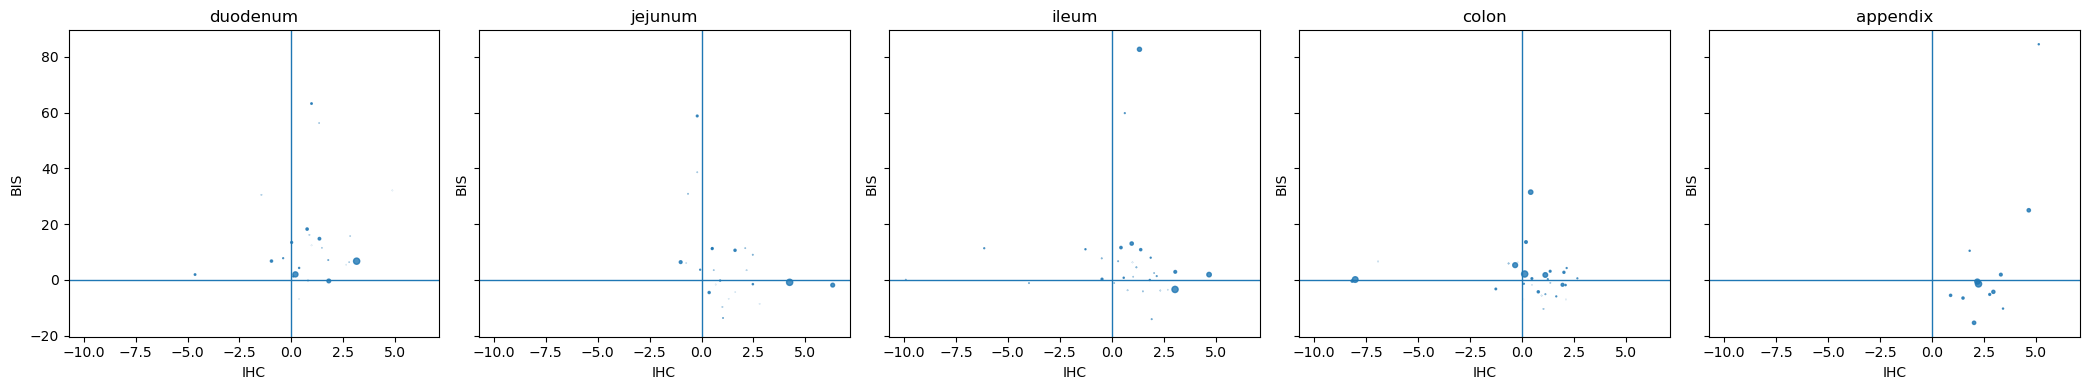

In [66]:
# Plot 1: healthy functional phase space by segment
segments_order = ["duodenum", "jejunum", "ileum", "colon", "appendix", "unknown"]
segments_present = [s for s in segments_order if s in state_summary["segment"].unique()]

n = len(segments_present)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.0), sharex=True, sharey=True)

if n == 1:
    axes = [axes]

for ax, seg in zip(axes, segments_present):
    sub = state_summary[state_summary["segment"] == seg].copy()
    x = sub["IHC_raw_mean"].values
    y = sub["BIS_raw_mean"].values
    sz = sub["n_cells"].values.astype(float)
    sz = 20.0 * (sz / np.nanmax(sz)) if np.nanmax(sz) > 0 else 20.0

    ax.scatter(x, y, s=sz, alpha=0.8)
    ax.set_title(seg)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("IHC")
    ax.set_ylabel("BIS")

plt.tight_layout()
plt.show()


In [67]:
# Decomposition: sample mean = composition component + expression component
# composition component uses global segment x state mean as baseline
baseline = (
    df.groupby(["segment", "cell_state"])
      .agg(BIS_base=("BIS_raw", "mean"), IHC_base=("IHC_raw", "mean"))
      .reset_index()
)

df2 = df.merge(baseline, on=["segment", "cell_state"], how="left")

# Sample-level state proportions and state means
g = df2.groupby(["segment", "sample_id", "cell_state"], dropna=False)

state_stats = g.agg(
    n=("BIS_raw", "size"),
    BIS_state_mean=("BIS_raw", "mean"),
    IHC_state_mean=("IHC_raw", "mean"),
    BIS_base=("BIS_base", "first"),
    IHC_base=("IHC_base", "first"),
).reset_index()

totals = state_stats.groupby(["segment", "sample_id"])["n"].sum().reset_index().rename(columns={"n": "n_total"})
state_stats = state_stats.merge(totals, on=["segment", "sample_id"], how="left")
state_stats["prop"] = state_stats["n"] / state_stats["n_total"]

# Components per sample
state_stats["BIS_comp_part"] = state_stats["prop"] * state_stats["BIS_base"]
state_stats["IHC_comp_part"] = state_stats["prop"] * state_stats["IHC_base"]

state_stats["BIS_expr_part"] = state_stats["prop"] * (state_stats["BIS_state_mean"] - state_stats["BIS_base"])
state_stats["IHC_expr_part"] = state_stats["prop"] * (state_stats["IHC_state_mean"] - state_stats["IHC_base"])

sample_components = (
    state_stats.groupby(["segment", "sample_id"])
      .agg(
          BIS_comp=("BIS_comp_part", "sum"),
          BIS_expr=("BIS_expr_part", "sum"),
          IHC_comp=("IHC_comp_part", "sum"),
          IHC_expr=("IHC_expr_part", "sum"),
          n_total=("n_total", "first"),
      )
      .reset_index()
)

sample_components["BIS_total"] = sample_components["BIS_comp"] + sample_components["BIS_expr"]
sample_components["IHC_total"] = sample_components["IHC_comp"] + sample_components["IHC_expr"]

sample_components.head()


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_87676/454730490.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["segment", "cell_state"])
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_87676/454730490.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df2.groupby(["segment", "sample_id", "cell_state"], dropna=False)
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_87676/454730490.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obs

,segment,sample_id,BIS_comp,BIS_expr,IHC_comp,IHC_expr,n_total,BIS_total,IHC_total
0,appendix,4918STDY7274839,0.0,0.0,0.0,0.0,0,0.0,0.0
1,appendix,4918STDY7333456,0.0,0.0,0.0,0.0,0,0.0,0.0
2,appendix,4918STDY7389431,0.0,0.0,0.0,0.0,0,0.0,0.0
3,appendix,4918STDY7447825,0.0,0.0,0.0,0.0,0,0.0,0.0
4,appendix,4918STDY7702680,0.0,0.0,0.0,0.0,0,0.0,0.0


In [68]:
df

,segment,tissue_layer,cell_state,BIS_raw,IHC_raw,BIS_seg_z,IHC_seg_z,sampled_site_condition,sample_collection_method,sex_ontology_term,age_range,dataset_id,donor_id,sample_id
0,colon,unknown,Cycling TA,26.039848,2.223420,1.171871,0.566852,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
1,colon,unknown,Absorptive TA,6.314091,-9.106392,0.067399,-1.271587,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
2,colon,unknown,Absorptive TA,4.067121,-1.595034,-0.058412,-0.052752,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
3,colon,unknown,Colonocytes Early,2.252424,-0.765158,-0.160019,0.081909,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
4,colon,unknown,Colonocytes Early,-1.896515,0.680297,-0.392324,0.316457,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274854,colon,mucosa,Secretory Goblet Cells,18.362879,1.010112,0.742027,0.369974,healthy,biopsy,male,60-69,Luoma2020,NC4,NC4_CD45
274855,colon,mucosa,Secretory Goblet Cells,15.781364,0.539444,0.597484,0.293601,healthy,biopsy,male,60-69,Luoma2020,NC4,NC4_CD45
274856,colon,mucosa,Colonocytes Late,-5.793939,0.506315,-0.610546,0.288225,healthy,biopsy,male,60-69,Luoma2020,NC4,NC4_CD45
274857,colon,mucosa,Enterocytes,-6.896970,0.054762,-0.672306,0.214954,healthy,biopsy,male,60-69,Luoma2020,NC4,NC4_CD45


In [69]:
# Attach stratifiers for optional coloring later
meta_cols = ["sample_id", "donor_id", "dataset_id", "sample_collection_method", "sampled_site_condition", "sex_ontology_term", "age_range", "segment"]
sample_meta = (
    df[meta_cols].drop_duplicates(subset=["sample_id", "segment"])
)

sample_components = sample_components.merge(sample_meta, on=["sample_id", "segment"], how="left")
sample_components.head()


,segment,sample_id,BIS_comp,BIS_expr,IHC_comp,IHC_expr,n_total,BIS_total,IHC_total,donor_id,dataset_id,sample_collection_method,sampled_site_condition,sex_ontology_term,age_range
0,appendix,4918STDY7274839,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,appendix,4918STDY7333456,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,appendix,4918STDY7389431,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,appendix,4918STDY7447825,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,appendix,4918STDY7702680,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


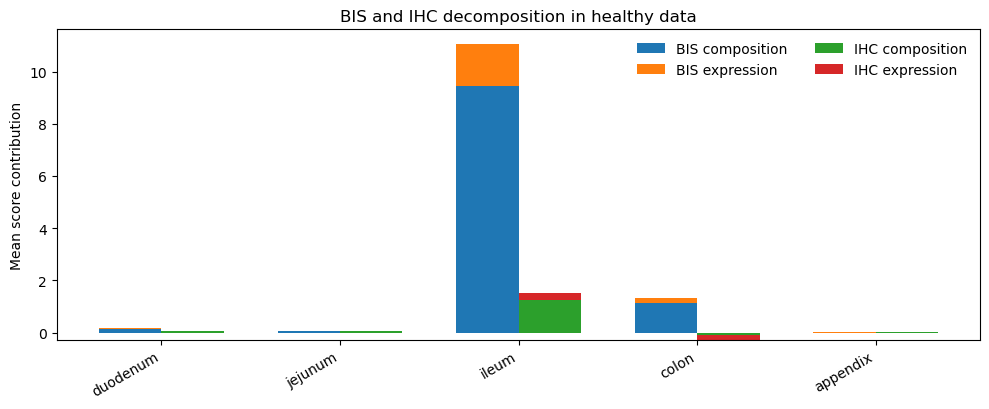

In [70]:
# Plot 2: expression vs composition breakdown by segment
seg_means = (
    sample_components.groupby("segment")
      .agg(
          BIS_comp=("BIS_comp", "mean"),
          BIS_expr=("BIS_expr", "mean"),
          IHC_comp=("IHC_comp", "mean"),
          IHC_expr=("IHC_expr", "mean"),
          n_samples=("sample_id", pd.Series.nunique),
      )
      .reset_index()
)

segments_present = [s for s in segments_order if s in seg_means["segment"].unique()]
seg_means = seg_means.set_index("segment").loc[segments_present].reset_index()

x = np.arange(len(seg_means))
w = 0.35

fig, ax = plt.subplots(figsize=(1.6 * len(seg_means) + 2, 4.2))

ax.bar(x - w/2, seg_means["BIS_comp"], width=w, label="BIS composition")
ax.bar(x - w/2, seg_means["BIS_expr"], width=w, bottom=seg_means["BIS_comp"], label="BIS expression")

ax.bar(x + w/2, seg_means["IHC_comp"], width=w, label="IHC composition")
ax.bar(x + w/2, seg_means["IHC_expr"], width=w, bottom=seg_means["IHC_comp"], label="IHC expression")

ax.set_xticks(x)
ax.set_xticklabels(seg_means["segment"], rotation=30, ha="right")
ax.set_ylabel("Mean score contribution")
ax.set_title("BIS and IHC decomposition in healthy data")
ax.legend(ncol=2, frameon=False)

plt.tight_layout()
plt.show()


In [71]:
# Optional: same decomposition but stratified within segment by sampled_site_condition
grp = (
    sample_components.groupby(["segment", "sampled_site_condition"])
      .agg(
          BIS_total=("BIS_total", "mean"),
          IHC_total=("IHC_total", "mean"),
          n_samples=("sample_id", pd.Series.nunique),
      )
      .reset_index()
)
grp.sort_values(["segment", "sampled_site_condition"]).head(20)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_87676/3332493707.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_components.groupby(["segment", "sampled_site_condition"])


,segment,sampled_site_condition,BIS_total,IHC_total,n_samples
0,appendix,adjacent,NaN,NaN,NaN
1,appendix,healthy,3.001033,2.217991,4.0
2,colon,adjacent,8.247937,-1.908903,11.0
3,colon,healthy,2.966574,-0.102145,109.0
4,duodenum,adjacent,NaN,NaN,NaN
5,duodenum,healthy,5.690231,1.851193,9.0
6,ileum,adjacent,17.186254,2.211585,94.0
7,ileum,healthy,19.116739,2.760797,130.0
8,jejunum,adjacent,NaN,NaN,NaN
9,jejunum,healthy,2.522975,3.105635,7.0


In [75]:
adata_epi.obs['tissue'].value_counts()

tissue
ileum                 182806
ascending colon        53883
duodenum                6837
transverse colon        5884
sigmoid colon           5559
colon                   5469
rectum                  5206
jejunum                 3930
descending colon        2102
small intestine         1910
caecum                  1175
vermiform appendix        98
Name: count, dtype: int64

In [76]:
adata

AnnData object with n_obs × n_vars = 274859 × 36353
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'closest_GCA_celltype_x', 'cell_type_atlas', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'co